# Gaussian Regressor

### Functions and Methods Used

* `plt.subplots(2, 3, figsize=(16, 7))`: Creates a figure with a grid of 2 rows and 3 columns of graphs.

* `RBF(10, (0.01, 1e2))`: Defines a Gaussian kernel of type Radial Basis Function with an initial length of 10 and optimization limits.

* `GaussianProcessRegressor(alpha=alpha, kernel=kernel)`: Creates a regression model based on Gaussian processes using the defined kernel and a noise level of `alpha`.

* `gp.fit(X_train, y_train)`: Trains the model with the training data.

* `gp.score(X_train, y_train)`: Calculates the coefficient of determination (R^2) on the training set.

` ... * `gp.score(X_test, y_test)`: Calculates the performance (R^2) on the test set.

* `gp.predict(X_train)`: Generates predictions for the training data.

* `gp.predict(X_test)`: Generates predictions for the test data.

* `plot(...)`: Plots the actual data and the model predictions on a subplot.

* `axs[set_type,column].plot(...)`: Plots points on the corresponding plots.

* `axs[set_type,column].set_title(label)`: Adds a title to each plot.

* `axs[set_type,column].grid()`: Displays a grid for easier visualization.

* `plt.show()`: Displays all generated plots. * `np.linspace(0,10,N)`: Creates 100 equally spaced values ​​between 0 and 10.
* `np.random.seed(10)`: Sets the random seed to obtain reproducible results.

* `np.random.randn(N)`: Generates random noise with a standard normal distribution.

* `X[:, np.newaxis]`: Transforms the vector `X` into a two-dimensional column array.

* `train_test_split(X, y, random_state=60)`: Splits the data into training and test sets.

* `model(X_train, y_train, X_test, y_test)`: Executes the entire process of training, predicting, and visualizing the model.

### Summary

This notebook implements a regression model using a Gaussian Process Regressor with the `scikit-learn` library. First, synthetic linear data with random noise is generated to simulate a real-world regression problem. Then, the data is divided into training and test sets to properly evaluate the model's performance.

The model is trained multiple times using different values ​​of the parameter `alpha`, which controls the level of noise or regularization of the Gaussian process. For each configuration, predictions and performance metrics are calculated for both training and test sets, and the results are plotted to compare how the value of `alpha` affects the model's fit and generalizability.

In [1]:
# =========================
# IMPORTACIÓN DE LIBRERÍAS
# =========================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process.kernels import RBF

In [6]:
# =========================
# Esta función entrena y evalúa varios modelos de regresión por procesos gaussianos con distintos
# valores de alpha, comparando gráficamente sus predicciones y rendimiento en los conjuntos de entrenamiento y prueba.
# =========================

def model(X_train, y_train, X_test, y_test):
  fig, axs = plt.subplots(2, 3, figsize=(16, 7))
  kernel = RBF(10, (0.01, 1e2))
  training = 0; testing = 1;
  for alpha, column in zip([0.06, 0.8, 5], range(3)):
    gp = GaussianProcessRegressor(alpha=alpha, kernel=kernel)
    gp.fit(X_train, y_train)

    for set_type, label in zip((training, testing), ('Training set', 'Testing set')):
      if set_type == training:
        #training accuracy
        training_score = gp.score(X_train, y_train)
        y_pred = gp.predict(X_train)
        plot(axs, X_train, y_train, y_pred, set_type, column, label + ', alpha = '+str(alpha)+', score: {:3.2f}'.format(training_score))
      else:
        #testing accuracy
        testing_score = gp.score(X_test, y_test)
        y_pred = gp.predict(X_test)
        plot(axs, X_test, y_test, y_pred, set_type, column, label+', alpha = '+str(alpha)+', score: {:3.2f}'.format(testing_score))
  plt.show()
  return

In [9]:
# =========================
# Esta función representa en una subgráfica los datos reales y las predicciones del modelo,
# añadiendo un título y una cuadrícula para facilitar su visualización.
# =========================

def plot(axs, data2D, target1D, predict1D, set_type, column, label):
  axs[set_type,column].plot(data2D, target1D, 'y.', markersize = 12)
  axs[set_type,column].plot(data2D, predict1D, 'k.', markersize = 6)
  axs[set_type,column].set_title(label)
  axs[set_type,column].grid()
  return

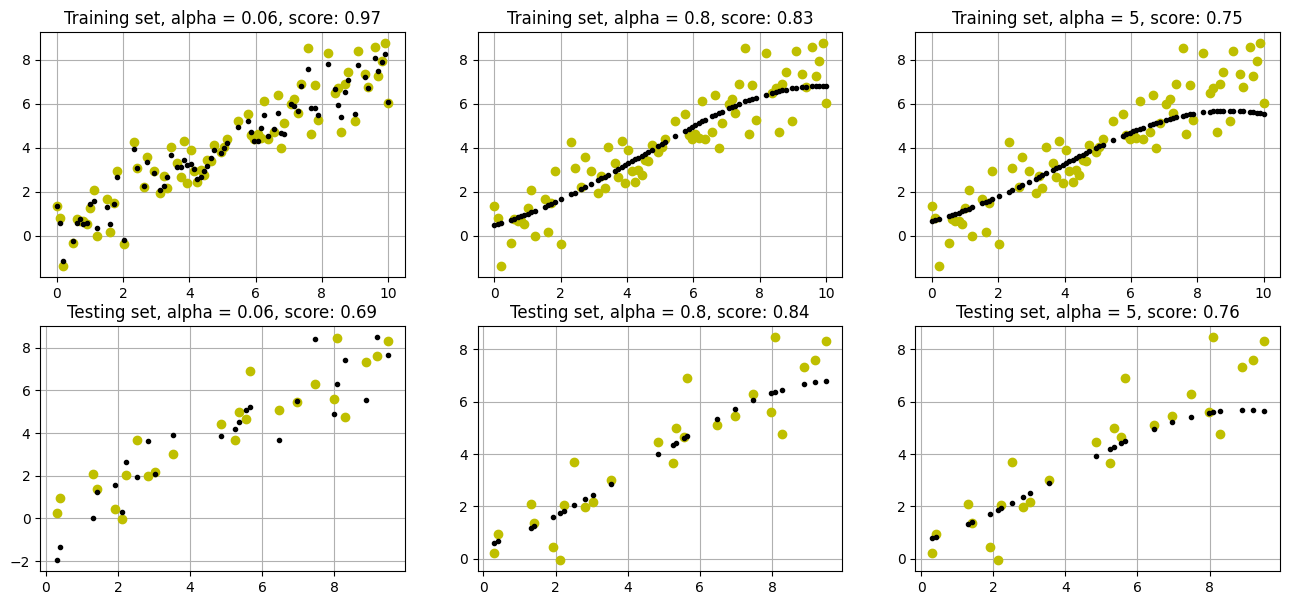

In [10]:
# =========================
# Este código genera un conjunto de datos sintéticos con una relación lineal y ruido aleatorio,
# lo divide en entrenamiento y prueba, y luego ejecuta el modelo de regresión para analizar su comportamiento.
# =========================

N = 100; X = np.linspace(0,10,N);
np.random.seed(10)
y = 0.8*X + np.random.randn(N)
X = X[:, np.newaxis]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 60)
model(X_train, y_train, X_test, y_test)